Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn. linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [2]:
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

Load Dataset

In [3]:
california = fetch_california_housing(as_frame=True)

df = california.frame.copy()
print(df.shape)
df.head(10)

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Multiple Linear Regression

In [6]:
target_col = 'MedHouseVal'

feature_cols = ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'Population', 'AveOccup']

X = df[feature_cols]
y = df[target_col]

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


In [7]:
print('Shape of X: ', X.shape)
print('Shape of y: ', y.shape)

Shape of X:  (20640, 6)
Shape of y:  (20640,)


In [8]:
corr_matrix = df[feature_cols + [target_col]].corr()
print("Correlation Matrix:\n",corr_matrix)

Correlation Matrix:
                MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             MedHouseVal  
MedInc          0.688075  
HouseAge        0.105623  
AveRooms        0.151948  
AveBedrms      -0.046701  
Population     -0.024650  
AveOccup       -0.023737  
MedHouseVal     1.000000  


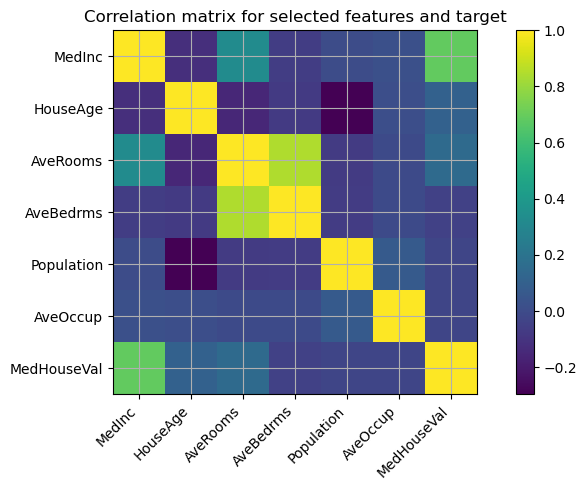

In [10]:
fig, ax = plt.subplots()
cax = ax.imshow(corr_matrix.values, interpolation = 'nearest')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation = 45, ha='right')
ax.set_yticklabels(corr_matrix.index)
fig.colorbar(cax)
ax.set_title('Correlation matrix for selected features and target')
plt.tight_layout()
plt.show()

Coding MLR on real data

In [11]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print('Traing Set size: ',X_train.shape[0], " rows")
print('Test Set size: ',X_test.shape[0], " rows")

Traing Set size:  16512  rows
Test Set size:  4128  rows


In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("Model Fitted Successfully")

Model Fitted Successfully


In [13]:
print("Intercept(bias term): ", lin_reg.intercept_)
print("\nCoefficients: ")
for feature_name, coef in zip(feature_cols, lin_reg.coef_):
    print(f'{feature_name} : {coef}') 

Intercept(bias term):  -0.5528727644615614

Coefficients: 
MedInc : 0.546160779107424
HouseAge : 0.016787909062567642
AveRooms : -0.22391994400479812
AveBedrms : 1.1154926114808357
Population : 2.3167197368248078e-05
AveOccup : -0.00461823134540709


In [14]:
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

print('Some Sample prediction of test set (first 5 rows):')
print('Predicted: ', y_test_pred[:5])
print('Actual: ', y_test.values[:5])

Some Sample prediction of test set (first 5 rows):
Predicted:  [1.00100537 1.56005635 2.67713262 2.64763331 1.98229968]
Actual:  [0.477   0.458   5.00001 2.186   2.78   ]


In [15]:
def regression_metrics(y_true, y_pred, label='Model'):
    mae = mean_absolute_error(y_true,y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true,y_pred)
    
    print(f"==={label}===")
    print('MAE: ',mae)
    print('MSE: ',mse)
    print('RMSE: ',rmse)
    print('R^2: ',r2)

In [16]:
#Evaluate on train and test
regression_metrics(y_train, y_train_pred, label='LinearRegression (Train)')
regression_metrics(y_test, y_test_pred, label='LinearRegression (Test)')

===LinearRegression (Train)===
MAE:  0.5708698051066731
MSE:  0.6070093832609208
RMSE:  0.7791080690513484
R^2:  0.5459161602818385
===LinearRegression (Test)===
MAE:  0.5792140665454439
MSE:  0.6421872314534861
RMSE:  0.801365853685747
R^2:  0.5099337366296423


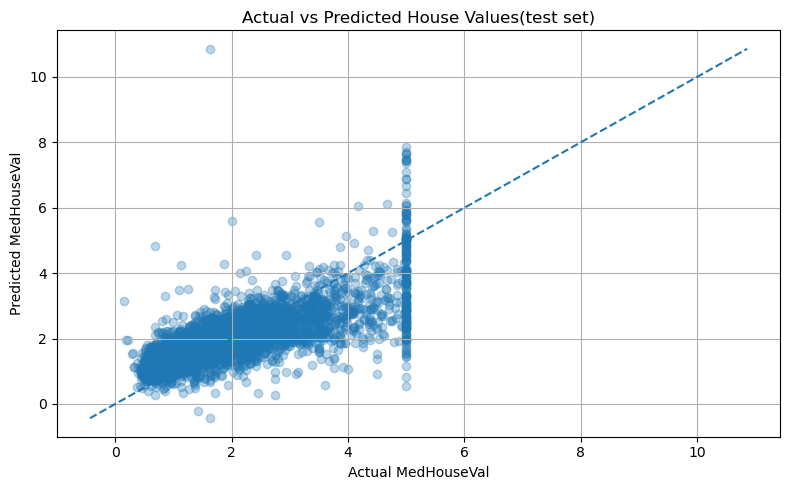

In [18]:
# Plot predicted vs actual values
plt.figure()
plt.scatter(y_test,y_test_pred,alpha=0.3)
plt.xlabel('Actual MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Actual vs Predicted House Values(test set)')

#Diagonal Reference Line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val,max_val],[min_val,max_val], linestyle='--')
plt.tight_layout()
plt.show()

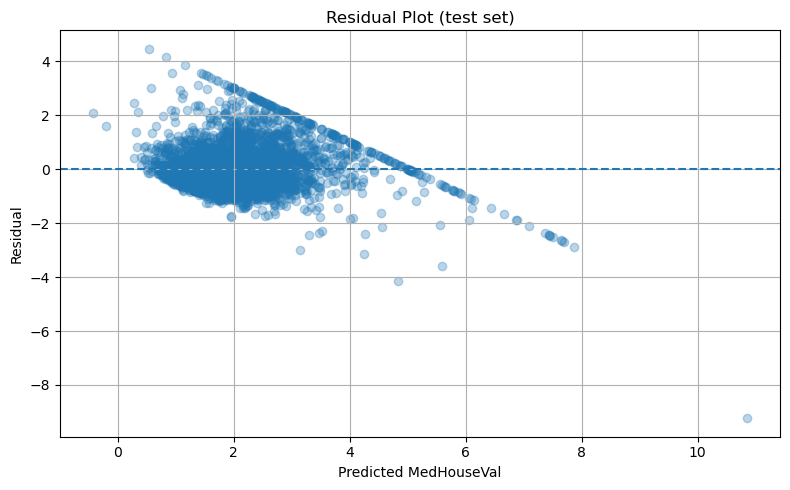

In [19]:
# Redsidual Plot (error = actual - predicted)
residuals = y_test - y_test_pred

plt.figure()
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted MedHouseVal')
plt.ylabel('Residual')
plt.title('Residual Plot (test set)')
plt.tight_layout()
plt.show()

1. Residual = 0    => Prefect prediction
2. Residual > 0    => Model predicted too low
3. Residual < 0    => Model predicted too high

### Polynomial Linear Regression

In [21]:
X_single = df[['MedInc']]
y_single = df[target_col]

X_single_train, X_single_test, y_single_train, y_single_test = train_test_split(X_single, y_single, test_size= .2,random_state=42)


print('Single Feature training shape: ', X_single_train.shape)
print('Single Feature test shape: ', X_single_test.shape)

Single Feature training shape:  (16512, 1)
Single Feature test shape:  (4128, 1)


In [22]:
lin_reg_single = LinearRegression()
lin_reg_single.fit(X_single_train, y_single_train)

y_single_test_pred = lin_reg_single.predict(X_single_test)

In [23]:
regression_metrics(y_single_test, y_single_test_pred, label='Single Feature Linear regression')

===Single Feature Linear regression===
MAE:  0.629908653009376
MSE:  0.7091157771765548
RMSE:  0.8420901241414454
R^2:  0.45885918903846656


c:\Users\adnan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


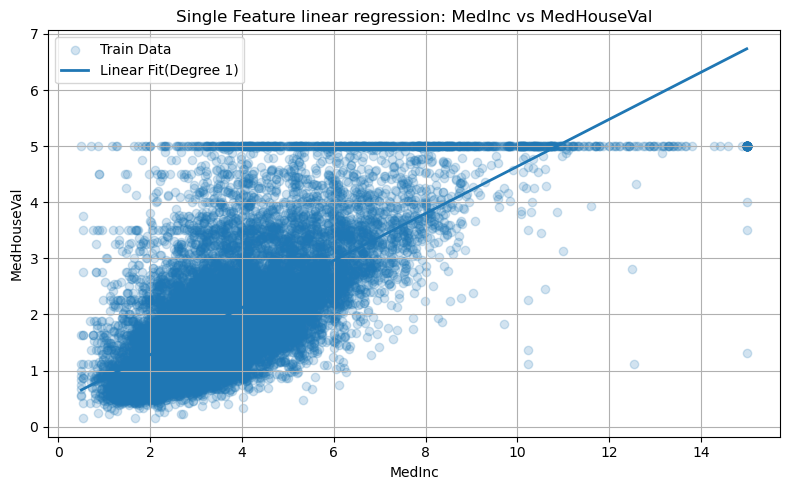

In [24]:
X_plot = np.linspace(X_single['MedInc'].min(), X_single['MedInc'].max(), 200).reshape(-1,1)

y_plot_lin = lin_reg_single.predict(X_plot)

plt.figure()
plt.scatter(X_single_train['MedInc'], y_single_train, alpha=0.2, label='Train Data')
plt.plot(X_plot, y_plot_lin, linewidth=2, label='Linear Fit(Degree 1)')
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.title('Single Feature linear regression: MedInc vs MedHouseVal')
plt.legend()
plt.tight_layout()
plt.show()

Coding Polynomial Regression on Real Data

In [32]:
degrees = [1,2,3,4,5,6,7,10]
results = []

for deg in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('lin_reg', LinearRegression())
    ])
    model.fit(X_single_train, y_single_train)
    y_train_pred_deg = model.predict(X_single_train)
    y_test_pred_deg = model.predict(X_single_test)
    
    mae_train = mean_absolute_error(y_single_train, y_train_pred_deg)
    rmse_train = np.sqrt(mean_squared_error(y_single_train,y_train_pred_deg))
    r2_train = r2_score(y_single_train,y_train_pred_deg)
    
    mae_test = mean_absolute_error(y_single_test, y_test_pred_deg)
    rmse_test = np.sqrt(mean_squared_error(y_single_test, y_test_pred_deg))
    r2_test = r2_score(y_single_test, y_test_pred_deg)
    
    results.append({
        'degree' : deg,
        'MAE_train' : mae_train,
        'RMSE_train' : rmse_train,
        'R^2_train' : r2_train, 
        'MAE_test' : mae_test,
        'RMSE_test' : rmse_test,
        'R^2_test' : r2_test, 
    })
    
    
results_df = pd.DataFrame(results)
results_df

,degree,MAE_train,RMSE_train,R^2_train,MAE_test,RMSE_test,R^2_test
0,1,0.624951,0.836149,0.476993,0.629909,0.842090,0.458859
1,2,0.624049,0.832459,0.481598,0.628292,0.838614,0.463318
2,3,0.615010,0.825033,0.490806,0.621896,0.835641,0.467116
3,4,0.615132,0.824950,0.490909,0.621889,0.835526,0.467262
4,5,0.614411,0.824844,0.491039,0.621369,0.835892,0.466796
5,6,0.613383,0.823919,0.492180,0.619966,0.834248,0.468891
6,7,0.612486,0.822268,0.494214,0.618768,0.832553,0.471047
7,10,0.613312,0.823325,0.492911,0.619886,0.834145,0.469022


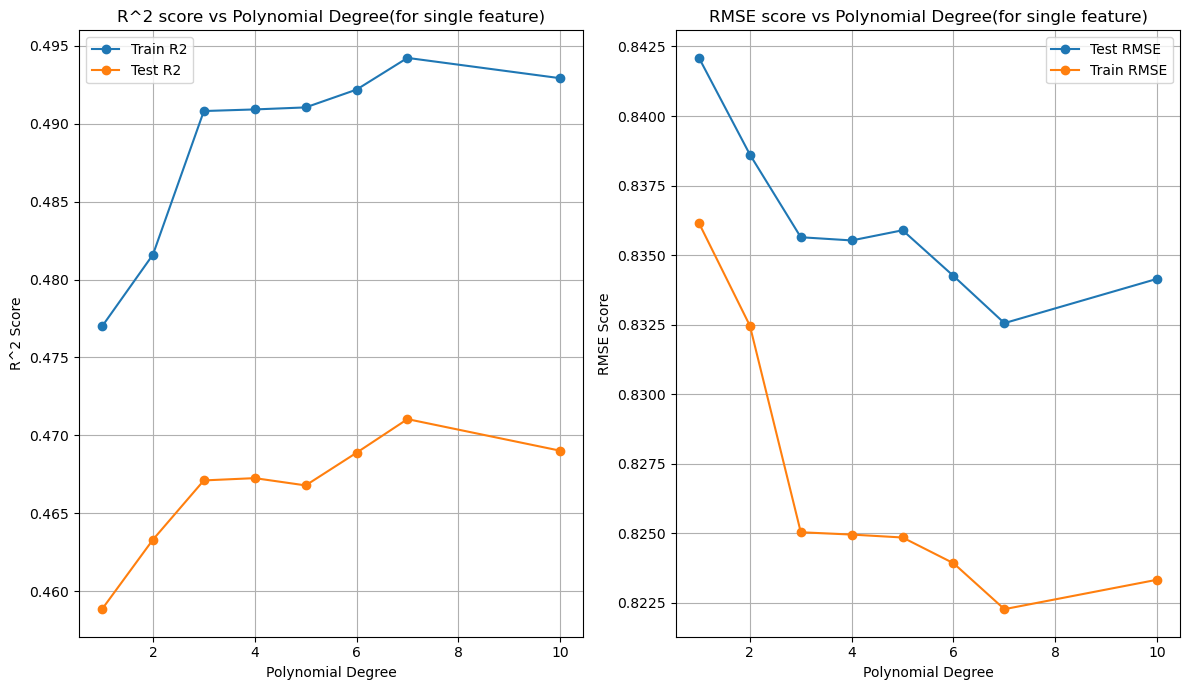

In [33]:
# Plot R squared and RMSE vs polynomial degree
fig, axes = plt.subplots(1,2,figsize=(12,7))

axes[0].plot(results_df['degree'], results_df['R^2_train'], marker='o', label='Train R2')
axes[0].plot(results_df['degree'], results_df['R^2_test'], marker='o', label='Test R2')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('R^2 Score')
axes[0].set_title("R^2 score vs Polynomial Degree(for single feature)")
axes[0].legend()

axes[1].plot(results_df['degree'], results_df['RMSE_test'], marker='o', label='Test RMSE')
axes[1].plot(results_df['degree'], results_df['RMSE_train'], marker='o', label='Train RMSE')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('RMSE Score')
axes[1].set_title("RMSE score vs Polynomial Degree(for single feature)")
axes[1].legend()

plt.tight_layout()
plt.show()

Polynomial Regression with Two Features

In [34]:
feature_cols_two = ['MedInc', 'HouseAge']
X_two = df[feature_cols_two]

X_two_train, X_two_test, y_two_train, y_two_test = train_test_split(
    X_two, y, test_size=0.2, random_state=42
)

deg = 2

poly_model_two = Pipeline([
    ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
    ('lin_reg', LinearRegression())
])

poly_model_two.fit(X_two_train, y_two_train)

y_two_test_pred = poly_model_two.predict(X_two_test)

regression_metrics(y_two_test, y_two_test_pred,
                   label='Polynomial regression (degree 2, two features)')

===Polynomial regression (degree 2, two features)===
MAE:  0.6013064394142872
MSE:  0.6499646827281104
RMSE:  0.806203871690102
R^2:  0.5039986038552433


In [35]:
# All features
X_all = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train-test split
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Polynomial Regression (degree 2) with all features
degree = 2

poly_all_model = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('lin_reg', LinearRegression())
])

poly_all_model.fit(X_all_train, y_all_train)

y_all_test_pred = poly_all_model.predict(X_all_test)

# Evaluation
regression_metrics(y_all_test, y_all_test_pred,
                   label='Polynomial Regression (degree 2, ALL features)')


===Polynomial Regression (degree 2, ALL features)===
MAE:  0.467000933246939
MSE:  0.4643015229510716
RMSE:  0.6813967441594299
R^2:  0.6456819735970121
